In [38]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import  silhouette_score
from sklearn import datasets
from scipy.cluster.hierarchy import dendrogram, linkage 
from scipy.cluster.hierarchy import dendrogram
from yellowbrick.cluster import SilhouetteVisualizer
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import fcluster, set_link_color_palette
import warnings
warnings.filterwarnings('ignore')
import math

In [2]:
df = pd.read_csv('shopping_trends.csv')

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

In [5]:
df.shape

(3900, 19)

In [6]:
df['Location'].unique()

<StringArray>
[      'Kentucky',          'Maine',  'Massachusetts',   'Rhode Island',
         'Oregon',        'Wyoming',        'Montana',      'Louisiana',
  'West Virginia',       'Missouri',       'Arkansas',         'Hawaii',
       'Delaware',  'New Hampshire',       'New York',        'Alabama',
    'Mississippi', 'North Carolina',     'California',       'Oklahoma',
        'Florida',          'Texas',         'Nevada',         'Kansas',
       'Colorado',   'North Dakota',       'Illinois',        'Indiana',
        'Arizona',         'Alaska',      'Tennessee',           'Ohio',
     'New Jersey',       'Maryland',        'Vermont',     'New Mexico',
 'South Carolina',          'Idaho',   'Pennsylvania',    'Connecticut',
           'Utah',       'Virginia',        'Georgia',       'Nebraska',
           'Iowa',   'South Dakota',      'Minnesota',     'Washington',
      'Wisconsin',       'Michigan']
Length: 50, dtype: str

In [7]:
df['Location'].nunique()

50

In [8]:
## Dropping columns Customer ID and Location
df_up = df.drop(columns=['Customer ID','Location'])

In [9]:
df_up

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [10]:
# ### Scaling numeric columns
# num_cols = df_up.select_dtypes(include=['int64','float64']).columns

# scaler = StandardScaler()

# df_up[num_cols] = scaler.fit_transform(df_up[num_cols])

In [11]:
df_up.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Size                      3900 non-null   str    
 6   Color                     3900 non-null   str    
 7   Season                    3900 non-null   str    
 8   Review Rating             3900 non-null   float64
 9   Subscription Status       3900 non-null   str    
 10  Payment Method            3900 non-null   str    
 11  Shipping Type             3900 non-null   str    
 12  Discount Applied          3900 non-null   str    
 13  Promo Code Used           3900 non-null   str    
 14  Previous Purchases 

In [12]:
df_up.select_dtypes(include=['int64','float64']).describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [13]:
## Applying get-dummies in categorical columns
df_encoded = pd.get_dummies(df_up,
                            dtype=int)

In [14]:
df_encoded

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,...,Preferred Payment Method_Debit Card,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,55,53,3.1,14,0,1,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
1,19,64,3.1,2,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,50,73,3.1,23,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,21,90,3.5,49,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,45,49,2.7,31,0,1,0,0,1,0,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,28,4.2,32,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3896,52,49,4.5,41,1,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3897,46,33,2.9,24,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
3898,44,77,3.8,24,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [15]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 99 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Age                                     3900 non-null   int64  
 1   Purchase Amount (USD)                   3900 non-null   int64  
 2   Review Rating                           3900 non-null   float64
 3   Previous Purchases                      3900 non-null   int64  
 4   Gender_Female                           3900 non-null   int32  
 5   Gender_Male                             3900 non-null   int32  
 6   Item Purchased_Backpack                 3900 non-null   int32  
 7   Item Purchased_Belt                     3900 non-null   int32  
 8   Item Purchased_Blouse                   3900 non-null   int32  
 9   Item Purchased_Boots                    3900 non-null   int32  
 10  Item Purchased_Coat                     3900 non-null   int32  
 11  It

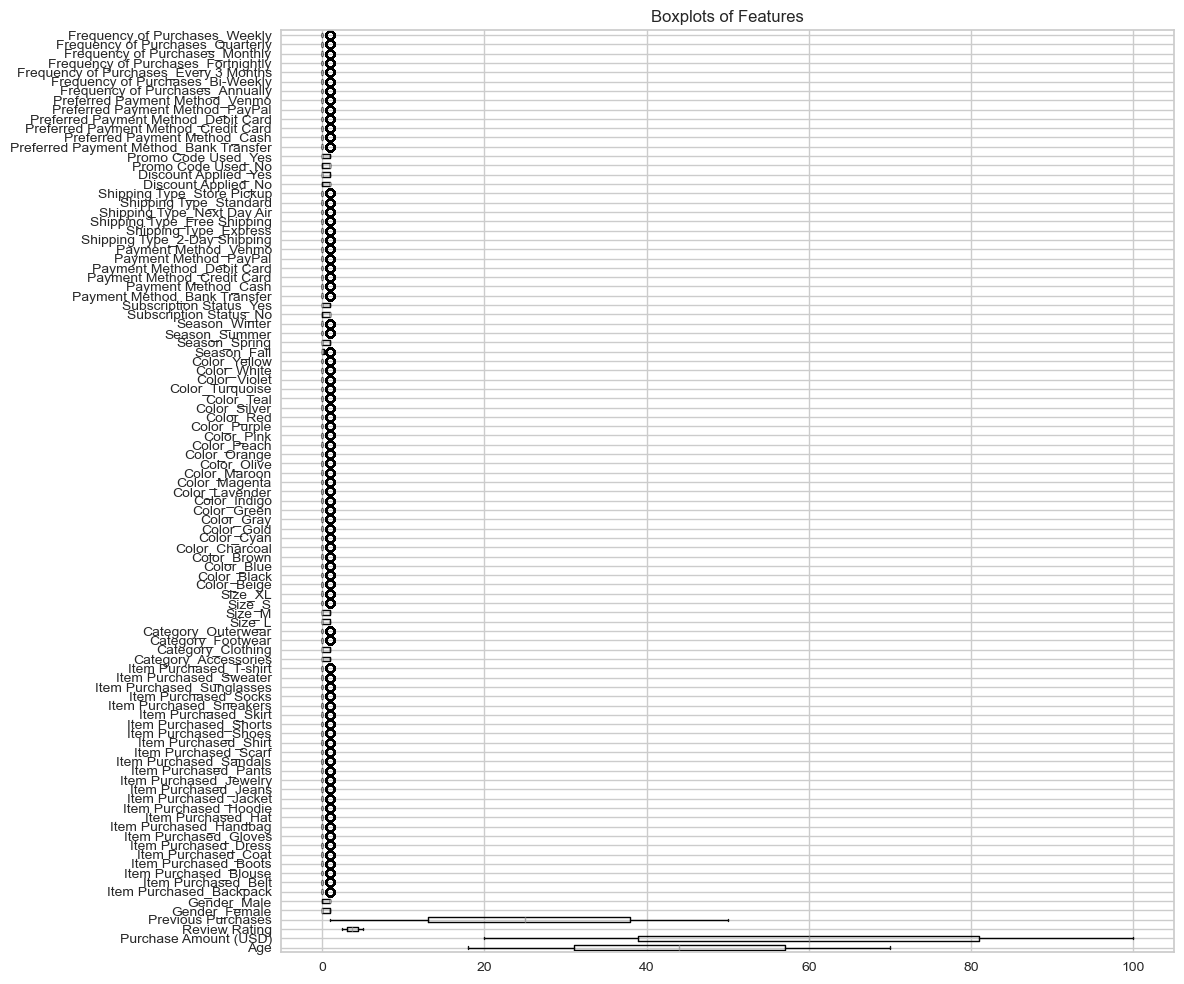

In [16]:
### Some boxplots for all features

plt.figure(figsize=(12, 10))
df_encoded.boxplot(vert=False)
plt.title("Boxplots of Features")
plt.tight_layout()
plt.show()

In [17]:
X = df_encoded.copy()

In [18]:
# # Hierarchical clustering -- Ward method
# dist_ward = linkage(X, method="ward")


# ## Dendrogram
# plt.figure(figsize=(18, 6))
# dendrogram(
#     dist_ward,
#     leaf_rotation=90,
#     color_threshold=740,      
#     above_threshold_color="grey"
# )
# plt.axhline(y=740, linestyle="--", linewidth=2)
# plt.xlabel("Index")
# plt.ylabel("Distance")
# plt.suptitle("Dendrogram for Customers Se Ward Method", fontsize=18)
# plt.show()

# labels_ward = fcluster(
#     dist_ward,
#     t=740,               
#     criterion="distance"
# )

# labels_ward = np.unique(labels_ward, return_inverse=True)[1]
# print("clusters:", np.unique(labels_ward))

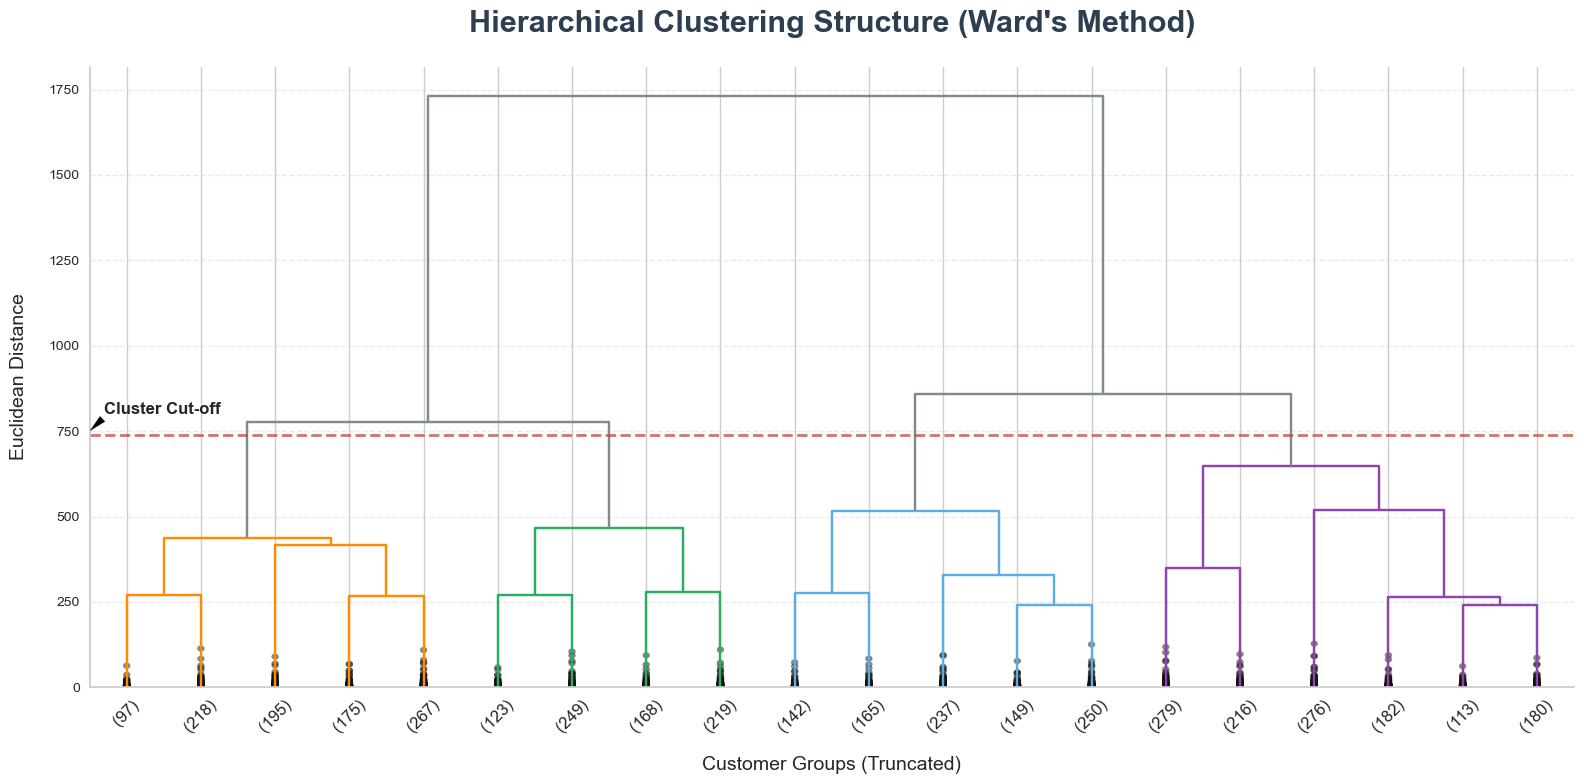

Successfully identified 4 Clusters


In [19]:
# --- STEP 1: Define the brand colors ---
brand_palette = ['#ff8c00', '#27ae60', '#5dade2', '#8e44ad']
set_link_color_palette(brand_palette)

# --- STEP 2: Calculate Linkage ---
dist_ward = linkage(X, method="ward")

# --- STEP 3: Create a high-end visualization ---
plt.figure(figsize=(16, 8), dpi=100)

# The 'truncate_mode' is the secret to a clean dendrogram
dn = dendrogram(
    dist_ward,
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=20,                   # Show the last 20 merges (much cleaner than 1000s of lines)
    leaf_rotation=45,
    leaf_font_size=12,
    color_threshold=740,    
    above_threshold_color="#7f8c8d", # Elegant slate grey for the main trunk
    show_contracted=True    # Shows little dots where branches were hidden
)

# --- STEP 4: Add a stylized threshold line ---
plt.axhline(y=740, color='#c0392b', linestyle='--', linewidth=2, alpha=0.7)
plt.annotate('Cluster Cut-off', xy=(0, 750), xytext=(2, 800),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=12, fontweight='bold')

# --- STEP 5: Clean up labels and title ---
plt.title("Hierarchical Clustering Structure (Ward's Method)", 
          fontsize=22, fontweight='bold', pad=25, color='#2c3e50')
plt.xlabel("Customer Groups (Truncated)", fontsize=14, labelpad=15)
plt.ylabel("Euclidean Distance", fontsize=14, labelpad=15)

# Remove the top and right spines for a modern "open" look
for spine in plt.gca().spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- STEP 6: Get the labels ---
labels_ward = fcluster(dist_ward, t=740, criterion="distance")
labels_ward = np.unique(labels_ward, return_inverse=True)[1]
print(f"Successfully identified {len(np.unique(labels_ward))} Clusters")

In [20]:
X["cluster_hier_ward"] = labels_ward

In [21]:
X

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,...,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly,cluster_hier_ward
0,55,53,3.1,14,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,3
1,19,64,3.1,2,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,50,73,3.1,23,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,3
3,21,90,3.5,49,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,1,2
4,45,49,2.7,31,0,1,0,0,1,0,...,1,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,28,4.2,32,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
3896,52,49,4.5,41,1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3897,46,33,2.9,24,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
3898,44,77,3.8,24,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,2


In [22]:
## Moving the customer id as first column in X
pad_hiercluster_df = pd.concat([df[['Customer ID']], X], axis=1)

In [23]:
pad_hiercluster_df.columns

Index(['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating',
       'Previous Purchases', 'Gender_Female', 'Gender_Male',
       'Item Purchased_Backpack', 'Item Purchased_Belt',
       'Item Purchased_Blouse',
       ...
       'Preferred Payment Method_PayPal', 'Preferred Payment Method_Venmo',
       'Frequency of Purchases_Annually', 'Frequency of Purchases_Bi-Weekly',
       'Frequency of Purchases_Every 3 Months',
       'Frequency of Purchases_Fortnightly', 'Frequency of Purchases_Monthly',
       'Frequency of Purchases_Quarterly', 'Frequency of Purchases_Weekly',
       'cluster_hier_ward'],
      dtype='str', length=101)

In [24]:
pad_hiercluster_df.shape

(3900, 101)

In [25]:
pad_hiercluster_df.head()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,...,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly,cluster_hier_ward
0,1,55,53,3.1,14,0,1,0,0,1,...,0,1,0,0,0,1,0,0,0,3
1,2,19,64,3.1,2,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,3,50,73,3.1,23,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,3
3,4,21,90,3.5,49,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,2
4,5,45,49,2.7,31,0,1,0,0,1,...,1,0,1,0,0,0,0,0,0,1


In [26]:
df_up

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [27]:
df_up['cluster'] = pad_hiercluster_df['cluster_hier_ward']

In [28]:
df_up.columns

Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status',
       'Payment Method', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases', 'cluster'],
      dtype='str')

In [29]:
## Applying a groupby method to understand if there are insights inside the clusters
df_up.groupby('cluster')[['Age','Purchase Amount (USD)','Review Rating','Previous Purchases']].mean()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
cluster,,,,
0,31.865546,37.553571,3.734349,21.090336
1,56.389987,37.766798,3.722003,31.743083
2,31.114528,81.801697,3.793955,26.994698
3,55.690209,73.455859,3.745586,23.470305


In [30]:
df_up.groupby('cluster')['Gender'].value_counts()

cluster  Gender
0        Male      651
         Female    301
1        Male      528
         Female    231
2        Male      647
         Female    296
3        Male      826
         Female    420
Name: count, dtype: int64

In [31]:
df_up.groupby('cluster')['Frequency of Purchases'].value_counts()

cluster  Frequency of Purchases
0        Every 3 Months            148
         Bi-Weekly                 145
         Fortnightly               137
         Annually                  132
         Monthly                   132
         Weekly                    131
         Quarterly                 127
1        Weekly                    120
         Annually                  118
         Monthly                   114
         Quarterly                 110
         Fortnightly               107
         Every 3 Months            104
         Bi-Weekly                  86
2        Every 3 Months            152
         Annually                  141
         Bi-Weekly                 138
         Quarterly                 133
         Weekly                    129
         Fortnightly               126
         Monthly                   124
3        Quarterly                 193
         Monthly                   183
         Annually                  181
         Every 3 Months         

In [32]:
cluster_names = {
    0: "Young Budget Buyers",
    1: "Mature Economy Customers",
    2: "Young Premium Shoppers",
    3: "Loyal Mature Customers"
}

In [33]:
df_up["customer_segment"] = df_up["cluster"].map(cluster_names)

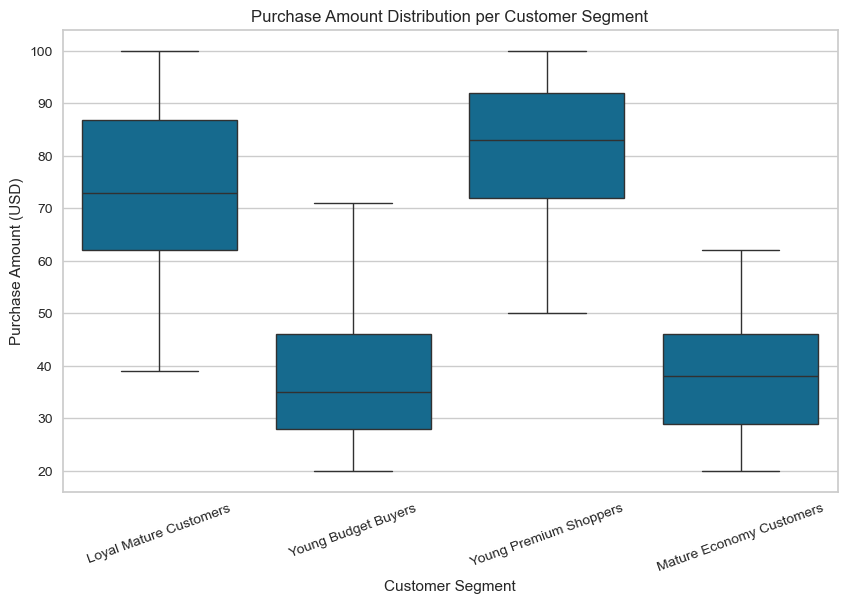

In [34]:
## Boxplot based on cluster and purchased amt
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='customer_segment',
    y='Purchase Amount (USD)',
    data=df_up,
    order=df_up['customer_segment'].unique()
)

plt.title("Purchase Amount Distribution per Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Purchase Amount (USD)")
plt.xticks(rotation=20)
plt.show()

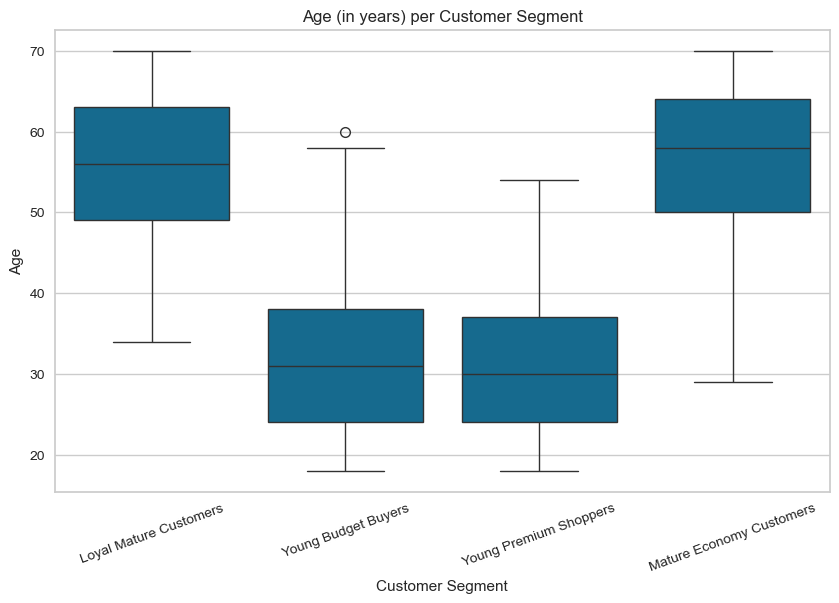

In [35]:
## Boxplot based on cluster and age
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='customer_segment',
    y='Age',
    data=df_up,
    order=df_up['customer_segment'].unique()
)

plt.title("Age (in years) per Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Age")
plt.xticks(rotation=20)
plt.show()

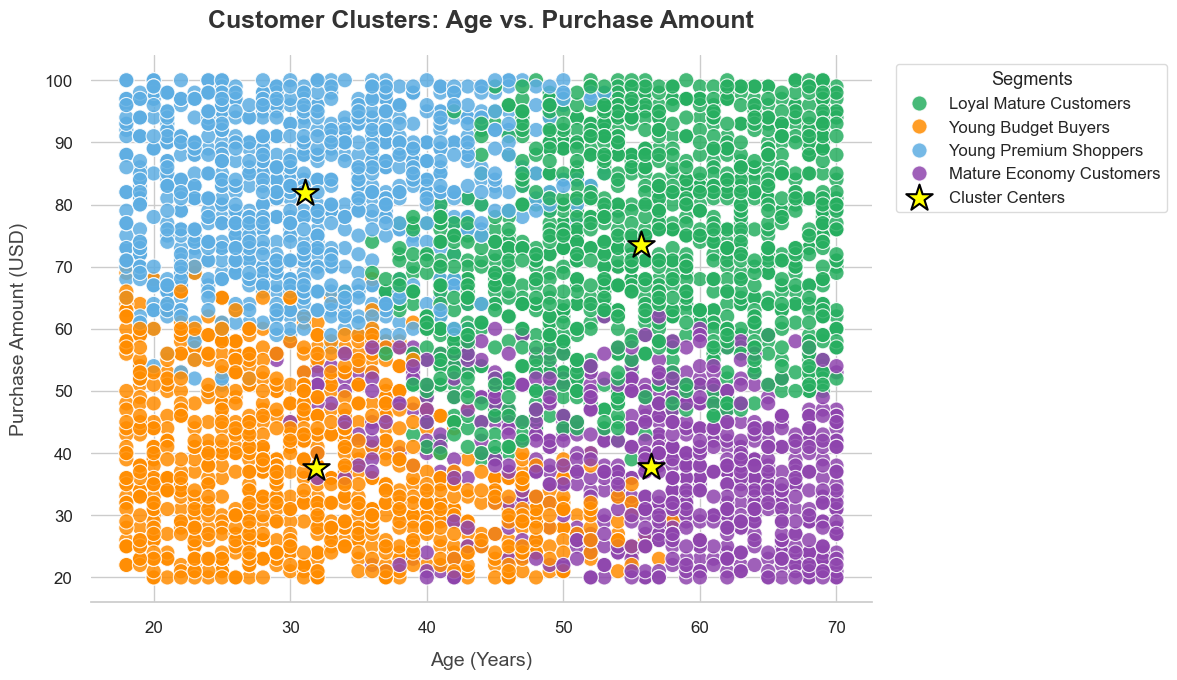

In [36]:
## Visualizing the clusters using the features Age and Purchase Amount.

# --- STEP 0: Map numeric clusters to descriptive names ---
# This ensures 'customer_segment' contains the strings Seaborn is looking for
cluster_mapping = {
    0: "Young Budget Buyers",
    1: "Mature Economy Customers",
    2: "Young Premium Shoppers",
    3: "Loyal Mature Customers"
}

# Create the segment column using the numeric 'cluster' column
# (Make sure 'cluster' is the name of your column with 0, 1, 2, 3)
df_up['customer_segment'] = df_up['cluster'].map(cluster_mapping)

# --- STEP 1: Set the global theme ---
sns.set_theme(style="whitegrid", font_scale=1.1)

# --- STEP 2: Define a custom color palette using the NEW names ---
custom_colors = {
    'Young Budget Buyers': '#ff8c00',    # Dark Orange
    'Loyal Mature Customers': '#27ae60', # Distinct Green
    'Young Premium Shoppers': '#5dade2', # Light Blue
    "Mature Economy Customers": '#8e44ad' # Rich Purple
}

# --- STEP 3: Set figure size ---
plt.figure(figsize=(12, 7))

# --- STEP 4: Create the main scatterplot ---
ax = sns.scatterplot(
    data=df_up,
    x='Age',
    y='Purchase Amount (USD)',
    hue='customer_segment',
    palette=custom_colors,
    s=120,                  
    alpha=0.85,             
    edgecolor='white',      
    linewidth=0.8,
    zorder=5 # Ensures points stay below centroids
)

# --- STEP 5: Calculate and Plot Cluster Centers (Centroids) ---
# Grouping by the new segment names so labels match
centroids = df_up.groupby('customer_segment')[['Age', 'Purchase Amount (USD)']].mean()

plt.scatter(
    x=centroids['Age'], 
    y=centroids['Purchase Amount (USD)'], 
    s=400,               
    c='yellow',          
    marker='*',          
    edgecolor='black',   
    linewidth=1.5,
    label='Cluster Centers', 
    zorder=10            
)

# --- STEP 6: Labels and Title ---
plt.title('Customer Clusters: Age vs. Purchase Amount', 
          fontsize=18, 
          fontweight='bold', 
          pad=20, 
          color='#333333')

plt.xlabel('Age (Years)', fontsize=14, labelpad=12, color='#444444')
plt.ylabel('Purchase Amount (USD)', fontsize=14, labelpad=12, color='#444444')

# --- STEP 7: Legend ---
plt.legend(
    title='Segments', 
    title_fontsize='13', 
    fontsize='12', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    frameon=True,
    edgecolor='lightgray'
)

# --- STEP 8: Final Touches ---
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

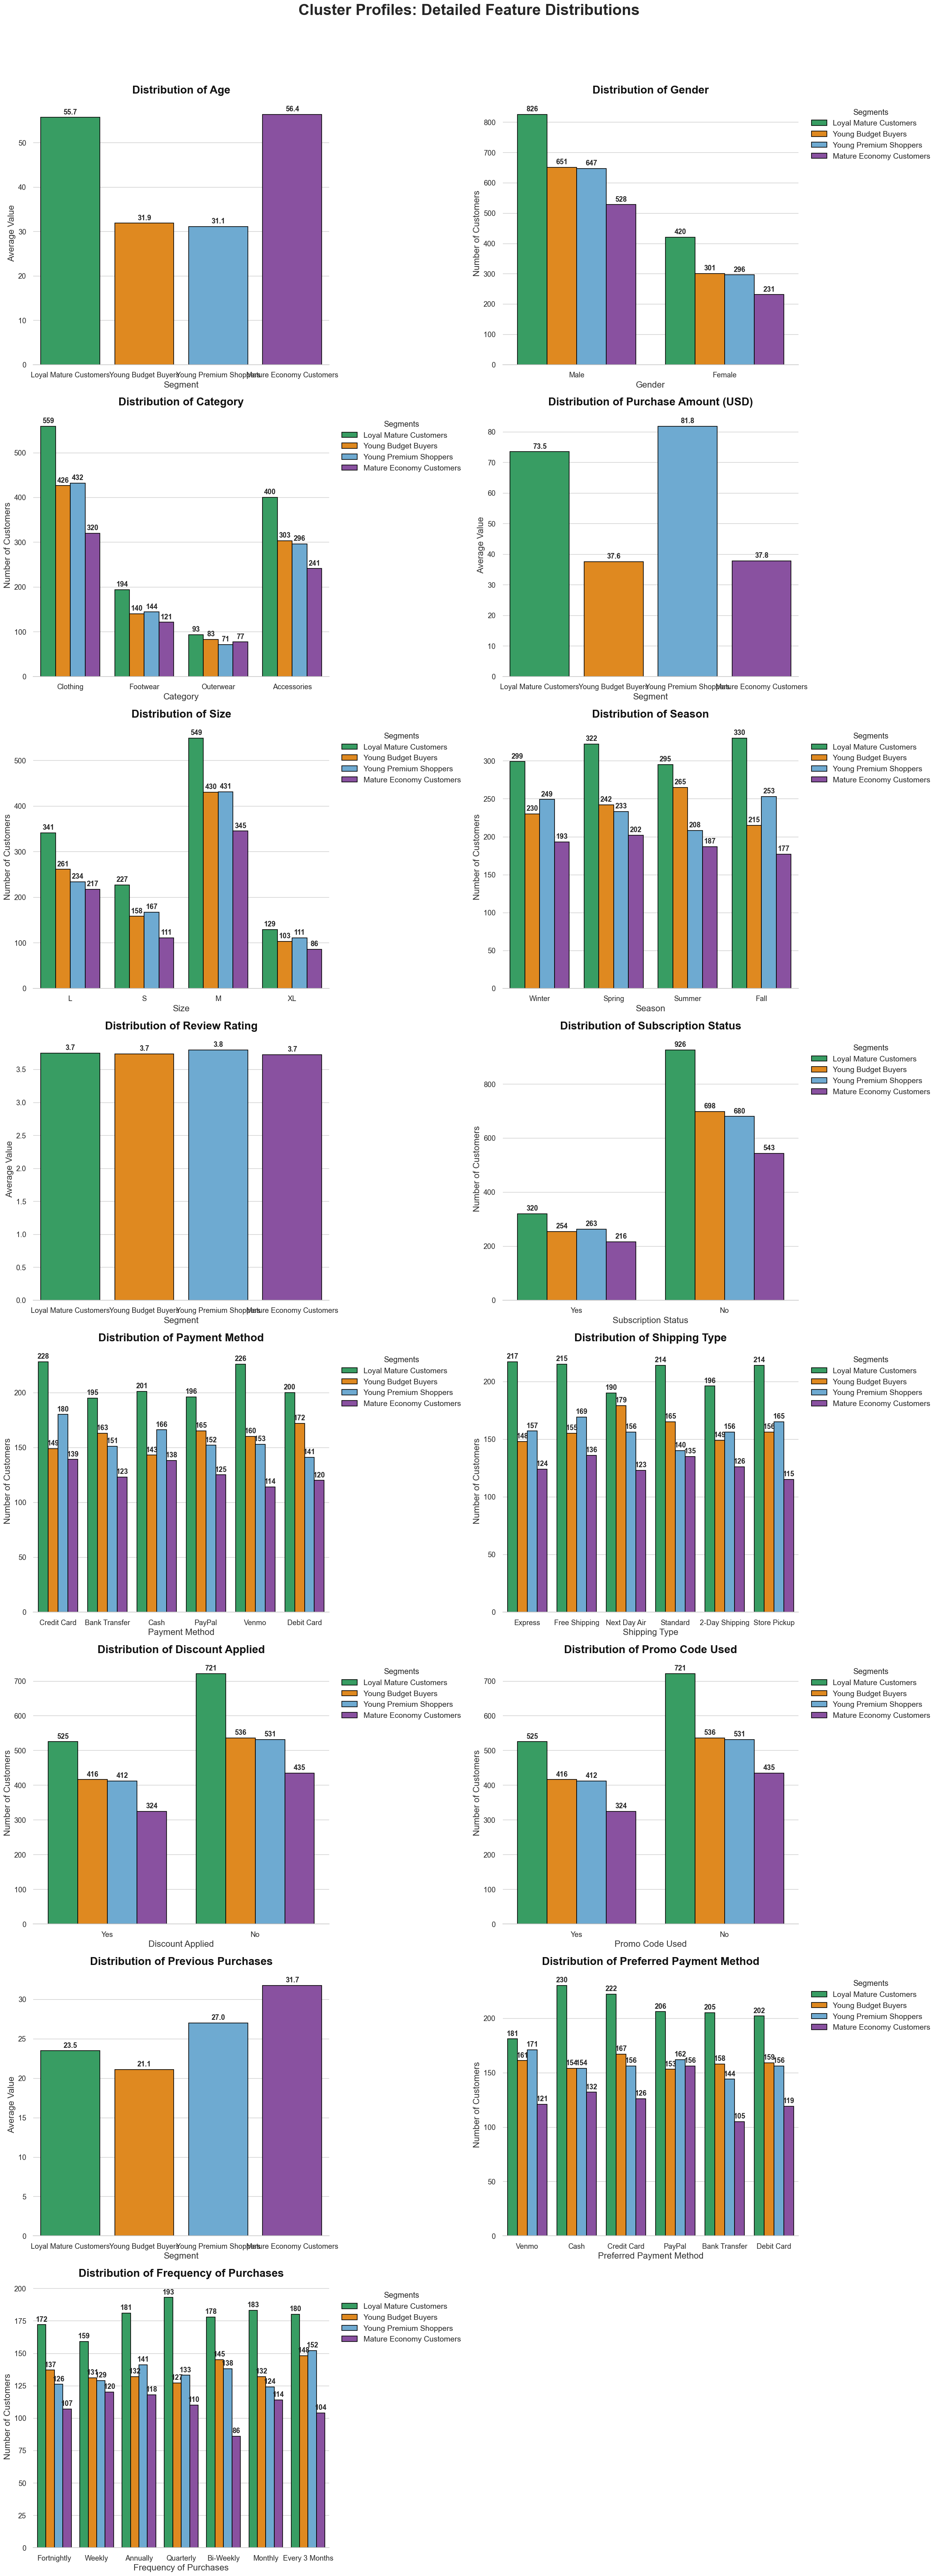

In [39]:
# --- STEP 0: Create the mapping and transform the data ---
cluster_mapping = {
    0: "Young Budget Buyers",
    1: "Mature Economy Customers",
    2: "Young Premium Shoppers",
    3: "Loyal Mature Customers"
}

# Create a clean segment column for plotting
df_up['customer_segment'] = df_up['cluster'].map(cluster_mapping)

# 1. Set theme and increase font sizes globally
sns.set_theme(style="whitegrid", font_scale=1.2)

# 2. Updated Custom Colors (Keys must match the names in cluster_mapping)
custom_colors = {
    'Young Budget Buyers': '#ff8c00',
    'Loyal Mature Customers': '#27ae60',
    'Young Premium Shoppers': '#5dade2',
    "Mature Economy Customers": '#8e44ad'
}

# 3. EXCLUDE specific columns 
# Note: Added 'customer_segment' to exclude if you don't want it plotted against itself
columns_to_exclude = ['cluster', 'Item Purchased', 'Color', 'customer_segment']
columns = [col for col in df_up.columns if col not in columns_to_exclude]

# 4. Grid setup
n_cols = 2 
n_rows = math.ceil(len(columns) / n_cols)

# 5. SUPER-SIZED Figure
plt.figure(figsize=(24, 8 * n_rows))

# 6. Loop through features 
for i, column in enumerate(columns):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    # --- NUMERICAL DATA ---
    if pd.api.types.is_numeric_dtype(df_up[column]):
        sns.barplot(
            data=df_up,
            x='customer_segment', # Updated to use names
            y=column, 
            ax=ax,
            hue='customer_segment', # Updated to use names          
            palette=custom_colors,   
            edgecolor='black',       
            linewidth=1.2,           
            errorbar=None,
            legend=False             
        )
        ax.set_ylabel('Average Value', fontsize=16, color='#333333')
        ax.set_xlabel('Segment', fontsize=16, color='#333333')
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=3, fontsize=13, fontweight='bold')
            
    # --- CATEGORICAL DATA ---
    else:
        sns.countplot(
            data=df_up,
            x=column,                                
            hue='customer_segment', # Updated to use names           
            ax=ax,
            palette=custom_colors,
            edgecolor='black',
            linewidth=1.2
        )
        ax.set_ylabel('Number of Customers', fontsize=16, color='#333333')
        ax.set_xlabel(column, fontsize=16, color='#333333')
        
        ax.legend(title='Segments', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='14')
        
        for container in ax.containers:
            ax.bar_label(container, padding=3, fontsize=13, fontweight='bold')
    
    # Beautify each subplot 
    ax.set_title(f"Distribution of {column}", fontsize=20, fontweight='bold', color='#111111', pad=15)
    sns.despine(left=True, bottom=False)

# 7. Add main title
plt.suptitle('Cluster Profiles: Detailed Feature Distributions', 
             fontsize=28, 
             fontweight='bold', 
             y=1.02)

# 8. Render
plt.tight_layout()
plt.show()

In [40]:
df_up_clust = pd.concat([df[['Customer ID']], df_up], axis=1)

In [41]:
df_up_clust

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,cluster,customer_segment
0,1,55,Male,Blouse,Clothing,53,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,3,Loyal Mature Customers
1,2,19,Male,Sweater,Clothing,64,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,0,Young Budget Buyers
2,3,50,Male,Jeans,Clothing,73,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,3,Loyal Mature Customers
3,4,21,Male,Sandals,Footwear,90,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,2,Young Premium Shoppers
4,5,45,Male,Blouse,Clothing,49,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,1,Mature Economy Customers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly,0,Young Budget Buyers
3896,3897,52,Female,Backpack,Accessories,49,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,1,Mature Economy Customers
3897,3898,46,Female,Belt,Accessories,33,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly,0,Young Budget Buyers
3898,3899,44,Female,Shoes,Footwear,77,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly,2,Young Premium Shoppers


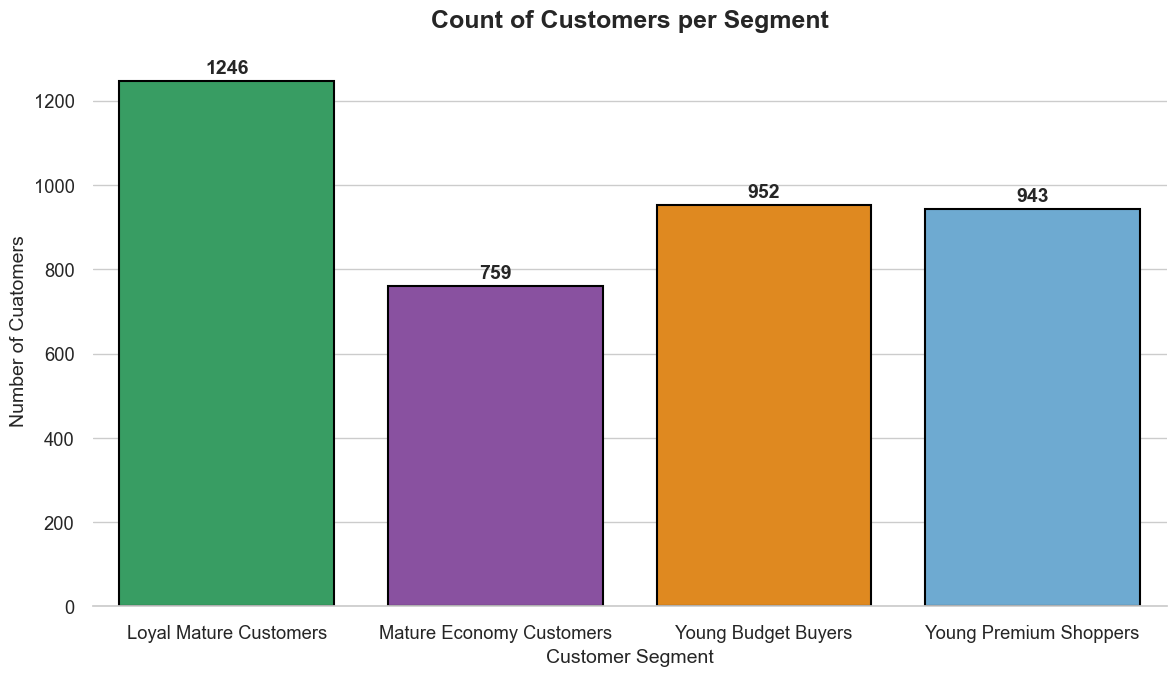

In [43]:
# 1. Prepare the data: Count unique Customer IDs per segment
# (Assuming your ID column is named 'Customer ID')
unique_counts = df_up_clust.groupby('customer_segment')['Customer ID'].nunique().reset_index()
unique_counts.columns = ['customer_segment', 'unique_count']

# 2. Set the style
sns.set_theme(style="whitegrid", font_scale=1.2)

# 3. Create the plot
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=unique_counts,
    x='customer_segment',
    y='unique_count',
    hue='customer_segment',
    palette=custom_colors,  # Using the dictionary we defined earlier
    edgecolor='black',
    linewidth=1.5,
    legend=False
)

# 4. Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=14, fontweight='bold')

# 5. Finalize labels and title
plt.title('Count of Customers per Segment', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Number of Cuatomers', fontsize=14)

# 6. Clean up
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

In [44]:
## export the clusters in csv in our folder
df_up_clust.to_csv("customer_segmentation.csv", index=False)